In [1]:
import os
target_dir = '/home/jovyan/NOC_NPD_Hackathon/PhD_Mixing/DataMerging'
os.chdir(target_dir)
import xarray as xr
from scipy import io
import numpy as np
import pandas as pd
import seawater as sw
import matplotlib.pyplot as plt
import cmocean
import gsw
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.interpolate import interp1d
# Loads useful functions
import ocean_function as of

/tmp/ipykernel_12800/167913554.py:8: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


# First, load datafiles

In [2]:
location = 4  # [0] Ridge, [1] West of Ridge, [2] East of Ridge Transect, [3] South Cross-Ridge Transect, [4] Cross-Ridge Transect
filename = ["RREX2015_Ridge_Merged.mat", "RREX2015_WRidge_Merged.mat", "RREX2015_ERidge_Merged.mat",
            "RREX2015_SouthXRidge_Merged.mat", "RREX2015_XRidge_Merged.mat"]
dsvmp = io.loadmat(filename[location])

#for all variables it only gets data from depth 3 to avoid noise close to the surface
lon_vmp = dsvmp["longitude"][0,:]
lat_vmp = dsvmp["latitude"][0,:]

pres_vmp = dsvmp["pres2d"][3:,0].astype(float)
epsilon = dsvmp["epsilon"][3:,:]
chi = dsvmp["chi"][3:,:]

grT = dsvmp["grT"][3:,:]
grS = dsvmp["grS"][3:,:]
grO = dsvmp["grO"][3:,:]
theta = dsvmp["theta"][3:,:]
salinity = dsvmp["salinity"][3:,:]
T = dsvmp["T"][3:,:]
gamman = dsvmp["gamman"][3:,:]
oxygen = dsvmp["oxygen"][3:,:]
grO = dsvmp["grO"][3:,:]

depth = np.full(theta.shape, np.nan)
for i in range(lon_vmp.size):
    for j in range(pres_vmp.size):
        depth[j,i] = sw.dpth(pres_vmp[j], lat_vmp[i])
        
print(min(lat_vmp))
print(max(lat_vmp))
print(min(lon_vmp))
print(max(lon_vmp))
grS.shape

57.585598
59.2964653333333
-35.7635988333333
-28.4417766666667


(997, 7)

In [3]:
#TEOS 10
pres2d = np.tile(pres_vmp, (lon_vmp.size,1)).T
Lon2d = np.tile(lon_vmp, (pres_vmp.size,1))
Lat2d = np.tile(lat_vmp, (pres_vmp.size,1))
print(salinity.shape)
SA = gsw.SA_from_SP(salinity,pres2d,Lon2d,Lat2d)
CT = gsw.CT_from_pt(SA,theta)
sigma0 = gsw.sigma0(SA, CT)+1000.
sp = gsw.spiciness0(SA,CT)

(997, 7)


In [4]:
gamman0 = np.copy(gamman)
#gamman = neutral-1000

## make section plot

Text(0.5, 1.0, '$\\theta$')

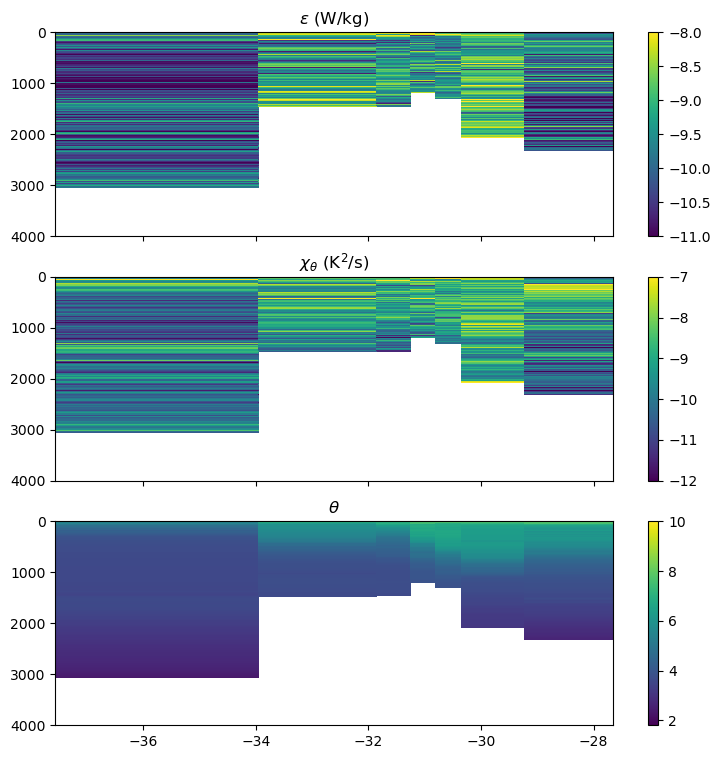

In [5]:
fig, ax = plt.subplots(3,1,sharex = True, sharey = True, figsize = (9,9))
#cc=ax[0].pcolor(lat_vmp, pres_vmp, np.log10(epsilon), vmin = -11, vmax = -8)
cc=ax[0].pcolor(lon_vmp, pres_vmp, np.log10(epsilon), vmin = -11, vmax = -8)
plt.colorbar(cc, ax = ax[0])
ax[0].set_ylim((4000,0))
ax[0].set_title("$\\varepsilon$ (W/kg)")

#cc=ax[1].pcolor(lat_vmp, pres_vmp, np.log10(chi), vmin = -12, vmax = -7)
cc=ax[1].pcolor(lon_vmp, pres_vmp, np.log10(chi), vmin = -12, vmax = -7)
plt.colorbar(cc, ax = ax[1])
ax[1].set_title("$\\chi_{\\theta}$ (K$^2$/s)")

cc=ax[2].pcolor(lon_vmp, pres_vmp, theta, vmin = 10, vmax = 2)
plt.colorbar(cc, ax = ax[2])
ax[2].set_title("$\\theta$")

# Sorts the density profiles (from low density to high density to remove overturns)

In [6]:
gamman_s = np.full(theta.shape, np.nan)
theta_s = np.full(theta.shape, np.nan)
salinity_s = np.full(salinity.shape, np.nan)
oxygen_s = np.full(salinity.shape, np.nan)
for i in range(lon_vmp.size):
    sg0 = gamman[:,i]
    iif = np.isfinite(sg0)
    gamman_s[iif,i] = np.sort(gamman[iif,i])
    iis = np.argsort(gamman[iif,i])
    theta_s[iif,i] =theta[iif,i][iis]
    salinity_s[iif,i] = salinity[iif,i][iis]
    oxygen_s[iif,i] = oxygen[iif,i][iis]


# Builds the smooth "mean flow" temperature and salinity profiles

In [7]:
import warnings
import numpy as np

# Universal polyfit warning suppression
warnings.filterwarnings('ignore', 
                       message='.*[Pp]olyfit.*poorly conditioned.*')
# Now all polyfit warnings will be suppressed in the entire notebook

h = 400 #defines the segment length
theta_mean = np.full(theta.shape, np.nan)
salinity_mean = np.full(theta.shape, np.nan)
oxygen_mean = np.full(theta.shape, np.nan)
for i in range(lon_vmp.size):
    for j in range(pres_vmp.size):
        deepest = np.where(np.isfinite(theta[:,i]))[0][-1]
        deepest_pres = pres_vmp[deepest]
        min_pres = pres_vmp[j]-h/2
        max_pres = pres_vmp[j]+h/2
        if min_pres<0:

            max_pres+=np.abs(min_pres)
            min_pres= 0
        if max_pres>deepest_pres:
            delta = max_pres-deepest_pres
            min_pres-=delta
            max_pres = np.copy(deepest_pres)

        jj = np.where( (pres_vmp>=min_pres) & (pres_vmp<=max_pres) & (np.isfinite(gamman_s[:,i])))[0]

        pt = np.polyfit(gamman_s[jj,i],theta_s[jj,i],4)
        ppt = np.poly1d(pt)
        theta_mean[j,i] = ppt(gamman_s[j,i])


        ps = np.polyfit(gamman_s[jj,i],salinity_s[jj,i],4)
        pps = np.poly1d(ps)
        salinity_mean[j,i] = pps(gamman_s[j,i])

        po = np.polyfit(gamman_s[jj,i],oxygen_s[jj,i],4)
        ppo = np.poly1d(po)
        oxygen_mean[j,i] = ppo(gamman_s[j,i])

# Calculates the "mean flow" temperature, salinity gradients and N2

In [8]:
grT_mean = np.full(theta.shape, np.nan)
grS_mean = np.full(theta.shape, np.nan)
grO_mean = np.full(theta.shape, np.nan)
N2 = np.full(theta.shape, np.nan)
for i in range(lon_vmp.size):
    
    for j in range(1,pres_vmp.size-1):
        grT_mean[j,i] = -(theta_mean[j+1,i] - theta_mean[j-1,i])/(depth[j+1,i] - depth[j-1,i])
        grS_mean[j,i] = -(salinity_mean[j+1,i] - salinity_mean[j-1,i])/(depth[j+1,i] - depth[j-1,i])
        grO_mean[j,i] = -(oxygen_mean[j+1,i] - oxygen_mean[j-1,i])/(depth[j+1,i] - depth[j-1,i])
        
        N2[j,i] = 9.81/1027*(gamman_s[j+1,i] -gamman_s[j-1,i])/(depth[j+1,i] - depth[j-1,i])

N2[N2<1e-8] = np.nan #removes very low N2 in the bottom boundary layer, which pose problems

# Caculates terms of the salinity and temperature variance budget

In [9]:
Krho = 0.2*epsilon/N2 #diapycnal diffusivity

chi_dia = 2*Krho*grT**2 #diapycnal production of thermal variance including fine scale: should be similar to chi

Pdia=  2*Krho*grT_mean**2 #diapycnal production of thermal on the mean flow profile

chiS = 2*Krho*grS**2 #diapycnal production of haline variance including fine scale: should be similar to chi

PdiaS=  2*Krho*grS_mean**2  #diapycnal production of haline on the mean flow profile

chiS[chiS>1e-4] = np.nan #removes some outlier

chiO = 2*Krho*grO**2 #diapycnal production of haline variance including fine scale: should be similar to chi

PdiaO=  2*Krho*grO_mean**2  #diapycnal production of haline on the mean flow profile

## tests that local diapycnal production roughly balances chi (like figure 2 in my paper)

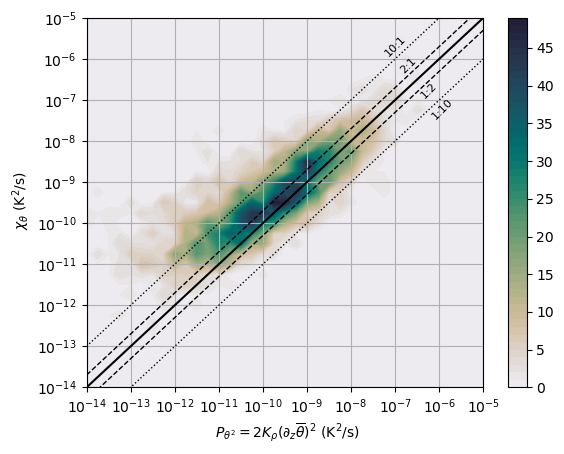

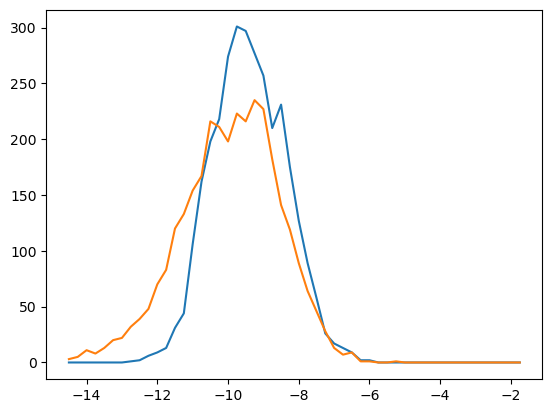

In [10]:
import cmocean 

dchi = 0.25
xchi = np.arange(-14.5,-1.5,dchi)
hist_chis = np.full((xchi.size, xchi.size), 0)
hist_chi_dia = np.full((xchi.size, xchi.size), 0)

for i in range(xchi.size):
    ii0 = (np.abs( np.log10(chi_dia)-xchi[i] )<dchi/2)
    hist_chi_dia[i] = np.sum(ii0)
    for j in range(xchi.size):
        ii = (np.abs( np.log10(chi)-xchi[i] )<dchi/2) & (np.abs( np.log10(chi_dia)-xchi[j] )<dchi/2)
        hist_chis[i,j] = np.sum(ii )

fig, ax = plt.subplots()
#ax.loglog(chi.ravel(), chi_dia0.ravel(),'.')
cc=ax.contourf(xchi,xchi, hist_chis,50, cmap  = cmocean.cm.rain)
cb = plt.colorbar(cc)
#cb.set_ticks(np.arange(0,4,1))
#cb.set_ticklabels( 10**np.arange(0,4,1))
ax.plot([-14,-3],[-14,-3],color = "k")
ax.plot([-14,-3],[-14+np.log10(10),-3+np.log10(10)],color = "k", ls = "dotted",lw = 1)
ax.plot([-14,-3],[-14-np.log10(10),-3-np.log10(10)],color = "k", ls = "dotted",lw = 1)
ax.plot([-14,-3],[-14+np.log10(2),-3+np.log10(2)],color = "k", ls = "--",lw = 1)
ax.plot([-14,-3],[-14-np.log10(2),-3-np.log10(2)],color = "k", ls = "--",lw = 1)

ax.annotate("10:1", xy = (-7,-6), ha = "center", va = "bottom", rotation = 45, fontsize = 8)
ax.annotate("2:1", xy = (np.log10(2e-7),np.log10(4e-7)), ha = "center", va = "bottom", rotation = 45, fontsize = 8)

ax.annotate("1:10", xy = (np.log10(1.2e-6),np.log10(1.2e-7)), ha = "center", va = "top", rotation = 45, fontsize = 8)
ax.annotate("1:2", xy = (np.log10(6e-7),np.log10(3e-7)), ha = "center", va = "top", rotation = 45, fontsize = 8)

ax.set_xlim((-14,-5))
ax.set_ylim((-14,-5))
ax.set_xticks(np.arange(-14,-4))
ax.set_xticklabels(["$10^{%s}$"%(x) for x in range(-14,-4)])
ax.set_yticks(np.arange(-14,-4))
ax.set_yticklabels(["$10^{%s}$"%(x) for x in range(-14,-4)])
ax.set_xlabel(" $ P_{\\theta^2} = 2 K_{\\rho} (\partial _{z} \\overline{\\theta})^2$ (K$^2$/s)")
ax.set_ylabel(" $\\chi_{\\theta}$ (K$^2$/s)")
ax.grid(True)

#fig.savefig("RREX2015_Ridge_chi_vs_localP.png", dpi =300, bbox_inches = "tight")
#fig.savefig("RREX2015_WRidge_chi_vs_localP.png", dpi =300, bbox_inches = "tight")
#fig.savefig("RREX2015_ERidge_chi_vs_localP.png", dpi =300, bbox_inches = "tight")

fig, ax = plt.subplots(1)
ax.plot(xchi, np.sum(hist_chis, axis = 1))
ax.plot(xchi, np.sum(hist_chis, axis = 0))

figname=["RREX2015_Ridge_chi_vs_localP.png","RREX2015_WRidge_chi_vs_localP.png","RREX2015_ERidge_chi_vs_localP.png",
         "RREX2015_SouthXRidge_chi_vs_localP.png","RREX2015_XRidge_chi_vs_localP.png"]
#fig.savefig(figname[location], dpi =300, bbox_inches = "tight")


# Makes some plots 

In [11]:
Pdia_m=of.moving_average(np.nanmean(Pdia[:,:], axis =1),30,window = "gauss")
PdiaS_m=of.moving_average(np.nanmean(PdiaS[:,:], axis =1),30,window = "gauss")
PdiaO_m=of.moving_average(np.nanmean(PdiaO[:,:], axis =1),30,window = "gauss")
chi_m=of.moving_average(np.nanmean(chi[:,:], axis =1),30,window = "gauss")
chi_dia_m=of.moving_average(np.nanmean(chi_dia[:,:], axis =1),30,window = "gauss")
chiS_m=of.moving_average(np.nanmean(chiS[:,:], axis =1),30,window = "gauss")
chiO_m=of.moving_average(np.nanmean(chiO[:,:], axis =1),30,window = "gauss")

dia_theta_percent=(np.nanmean(Pdia_m/chi_m))*100
dia_theta_percent=np.round(dia_theta_percent,decimals=1)

dia_S_percent=(np.nanmean(PdiaS_m/chiS_m))*100
dia_S_percent=np.round(dia_S_percent,decimals=1)

dia_O_percent=(np.nanmean(PdiaO_m/chiO_m))*100
dia_O_percent=np.round(dia_O_percent,decimals=1)

/tmp/ipykernel_12800/2794990097.py:1: RuntimeWarning: Mean of empty slice
  Pdia_m=of.moving_average(np.nanmean(Pdia[:,:], axis =1),30,window = "gauss")
/tmp/ipykernel_12800/2794990097.py:2: RuntimeWarning: Mean of empty slice
  PdiaS_m=of.moving_average(np.nanmean(PdiaS[:,:], axis =1),30,window = "gauss")
/tmp/ipykernel_12800/2794990097.py:3: RuntimeWarning: Mean of empty slice
  PdiaO_m=of.moving_average(np.nanmean(PdiaO[:,:], axis =1),30,window = "gauss")
/tmp/ipykernel_12800/2794990097.py:4: RuntimeWarning: Mean of empty slice
  chi_m=of.moving_average(np.nanmean(chi[:,:], axis =1),30,window = "gauss")
/tmp/ipykernel_12800/2794990097.py:5: RuntimeWarning: Mean of empty slice
  chi_dia_m=of.moving_average(np.nanmean(chi_dia[:,:], axis =1),30,window = "gauss")
/tmp/ipykernel_12800/2794990097.py:6: RuntimeWarning: Mean of empty slice
  chiS_m=of.moving_average(np.nanmean(chiS[:,:], axis =1),30,window = "gauss")
/tmp/ipykernel_12800/2794990097.py:7: RuntimeWarning: Mean of empty slice


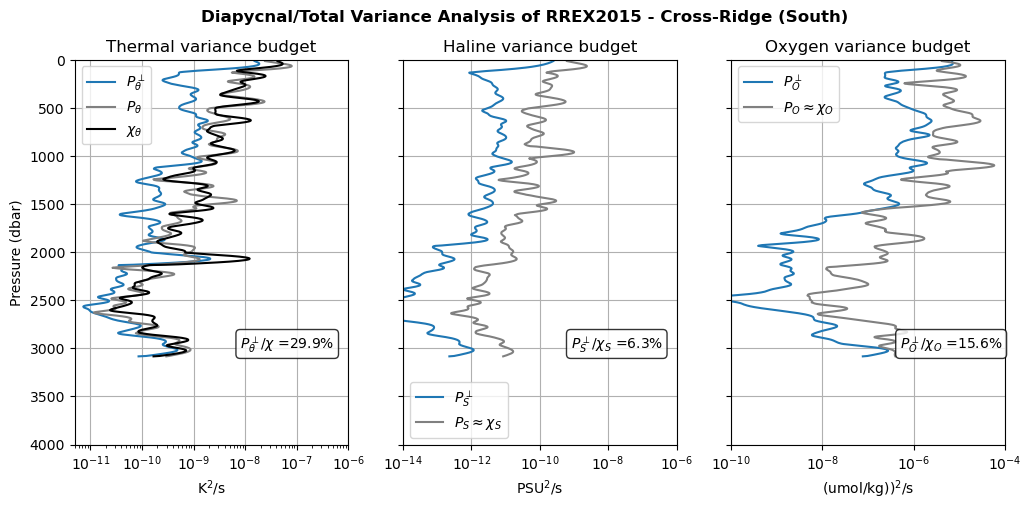

In [12]:
fig, ax = plt.subplots(1,3, sharey = True, figsize = (12,5))


ax[0].semilogx(Pdia_m, pres_vmp,label ="$P_{\\theta}^{\\perp}$")
ax[0].semilogx(chi_dia_m, pres_vmp, color = "gray", label ="$P_{\\theta}$" )
ax[0].semilogx(chi_m,  pres_vmp, color = "k", label = "$\chi_{\\theta}$")
ax[0].set_ylim((4000,0))
ax[0].set_xlim((5e-12,1e-6))
ax[0].legend()
ax[0].set_ylabel("Pressure (dbar)")
ax[0].set_title("Thermal variance budget")
ax[0].set_xlabel("K$^2$/s")
ax[0].grid(True)
ax[0].text(8e-9, 3000, '$P_{\\theta}^{\\perp}/\chi$ =' + f'{dia_theta_percent}%', 
           fontsize=10,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax[1].semilogx(PdiaS_m, pres_vmp,label ="$P_S^{\\perp}$")
ax[1].semilogx(chiS_m, pres_vmp, color = "gray", label = "$P_S \\approx \chi_S$")
ax[1].legend()
ax[1].set_title("Haline variance budget")
ax[1].set_xlabel("PSU$^2$/s")
ax[1].grid(True)
ax[1].set_ylim((4000,0))
ax[1].set_xlim((1e-14,1e-6))
ax[1].text(8e-10, 3000, '$P_S^{\\perp}/\chi_S$ =' + f'{dia_S_percent}%', 
           fontsize=10,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax[2].semilogx(PdiaO_m, pres_vmp,label ="$P_O^{\\perp}$")
ax[2].semilogx(chiO_m, pres_vmp, color = "gray", label = "$P_O \\approx \chi_O$")
ax[2].legend()
ax[2].set_title("Oxygen variance budget")
ax[2].set_xlabel("(umol/kg))$^2$/s")
ax[2].grid(True)
ax[2].set_ylim((4000,0))
ax[2].set_xlim((1e-10,1e-4))
ax[2].text(5e-7, 3000, '$P_O^{\\perp}/\chi_O$ =' + f'{dia_O_percent}%', 
           fontsize=10,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

figtitle=['Diapycnal/Total Variance Analysis of RREX2015 - Reykjanes Ridge',
          'Diapycnal/Total Variance Analysis of RREX2015 - West of Ridge',
          'Diapycnal/Total Variance Analysis of RREX2015 - East of Ridge',
          'Diapycnal/Total Variance Analysis of RREX2015 - Cross-Ridge',
          'Diapycnal/Total Variance Analysis of RREX2015 - Cross-Ridge (South)']
          
plt.suptitle(figtitle[location],fontsize=12,fontweight='bold')

figname=['RREX2015_Ridge_VarianceBudget_Merged.png',
         'RREX2015_WRidge_VarianceBudget_Merged.png',
         'RREX2015_ERidge_VarianceBudget_Merged.png',
         'RREX2015_SouthXRidge_VarianceBudget_Merged.png',
         'RREX2015_XRidge_VarianceBudget_Merged.png']

#plt.savefig(figname[location]) 


# Caculates terms of the salinity and temperature variance budget but using Kp derived from Osborn

In [13]:
# Calculate the _mean profiles in pressure coordinates instead of density ones
theta_mean_oz = np.full(theta.shape, np.nan)
salinity_mean_oz = np.full(theta.shape, np.nan)
oxygen_mean_oz = np.full(theta.shape, np.nan)

# Low pass method
n=75 # Window ~ 300 meters
for i in range(lon_vmp.size):
    theta_mean_oz[:,i]=of.moving_average(theta[:,i],n,window = "gauss")
    salinity_mean_oz[:,i]=of.moving_average(salinity[:,i],n,window = "gauss")
    oxygen_mean_oz[:,i]=of.moving_average(oxygen[:,i],n,window = "gauss")


grT_mean_oz = np.full(theta.shape, np.nan)
grS_mean_oz = np.full(theta.shape, np.nan)
grO_mean_oz = np.full(theta.shape, np.nan)
for i in range(lon_vmp.size):
    
    for j in range(1,pres_vmp.size-1):
        grT_mean_oz[j,i] = -(theta_mean_oz[j+1,i] - theta_mean_oz[j-1,i])/(depth[j+1,i] - depth[j-1,i])
        grS_mean_oz[j,i] = -(salinity_mean_oz[j+1,i] - salinity_mean_oz[j-1,i])/(depth[j+1,i] - depth[j-1,i])
        grO_mean_oz[j,i] = -(oxygen_mean_oz[j+1,i] - oxygen_mean_oz[j-1,i])/(depth[j+1,i] - depth[j-1,i])



In [14]:
# The same but deriving Krho using Osborn
chi_oz = np.full(chi.shape, np.nan)
grT2_oz = np.full(chi.shape, np.nan)
grT2=grT**2

n=15 # Window ~ 60 meters
for i in range(lon_vmp.size):
    chi_oz[:,i]=of.moving_average(chi[:,i],n,window = "gauss")
    grT2_oz[:,i]=of.moving_average(grT2[:,i],n,window = "gauss")

Krho_oz = chi_oz/(2*grT2_oz) #diapycnal diffusivity

chi_dia_oz = 2*Krho_oz*grT2 #diapycnal production of thermal variance including fine scale: should be similar to chi

Pdia_oz=  2*Krho_oz*grT_mean_oz**2 #diapycnal production of thermal on the mean flow profile

chiS_oz = 2*Krho_oz*grS**2 #diapycnal production of haline variance including fine scale: should be similar to chi

PdiaS_oz=  2*Krho_oz*grS_mean_oz**2  #diapycnal production of haline on the mean flow profile

chiS_oz[chiS_oz>1e-4] = np.nan #removes some outlier

chiO_oz = 2*Krho_oz*grO**2 #diapycnal production of haline variance including fine scale: should be similar to chi

PdiaO_oz=  2*Krho_oz*grO_mean_oz**2  #diapycnal production of haline on the mean flow profile

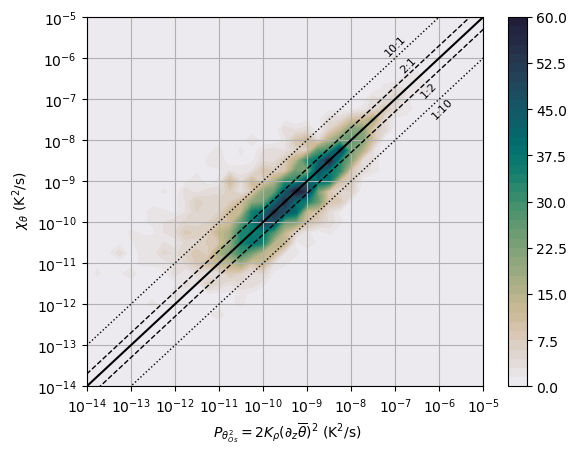

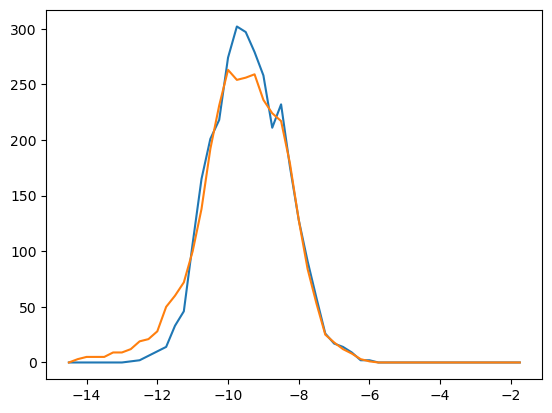

In [15]:
import cmocean 

dchi = 0.25
xchi = np.arange(-14.5,-1.5,dchi)
hist_chis = np.full((xchi.size, xchi.size), 0)
hist_chi_dia = np.full((xchi.size, xchi.size), 0)

for i in range(xchi.size):
    ii0 = (np.abs( np.log10(chi_dia_oz)-xchi[i] )<dchi/2)
    hist_chi_dia[i] = np.sum(ii0)
    for j in range(xchi.size):
        ii = (np.abs( np.log10(chi)-xchi[i] )<dchi/2) & (np.abs( np.log10(chi_dia_oz)-xchi[j] )<dchi/2)
        hist_chis[i,j] = np.sum(ii )

fig, ax = plt.subplots()
#ax.loglog(chi.ravel(), chi_dia0.ravel(),'.')
cc=ax.contourf(xchi,xchi, hist_chis,50, cmap  = cmocean.cm.rain)
cb = plt.colorbar(cc)
#cb.set_ticks(np.arange(0,4,1))
#cb.set_ticklabels( 10**np.arange(0,4,1))
ax.plot([-14,-3],[-14,-3],color = "k")
ax.plot([-14,-3],[-14+np.log10(10),-3+np.log10(10)],color = "k", ls = "dotted",lw = 1)
ax.plot([-14,-3],[-14-np.log10(10),-3-np.log10(10)],color = "k", ls = "dotted",lw = 1)
ax.plot([-14,-3],[-14+np.log10(2),-3+np.log10(2)],color = "k", ls = "--",lw = 1)
ax.plot([-14,-3],[-14-np.log10(2),-3-np.log10(2)],color = "k", ls = "--",lw = 1)

ax.annotate("10:1", xy = (-7,-6), ha = "center", va = "bottom", rotation = 45, fontsize = 8)
ax.annotate("2:1", xy = (np.log10(2e-7),np.log10(4e-7)), ha = "center", va = "bottom", rotation = 45, fontsize = 8)

ax.annotate("1:10", xy = (np.log10(1.2e-6),np.log10(1.2e-7)), ha = "center", va = "top", rotation = 45, fontsize = 8)
ax.annotate("1:2", xy = (np.log10(6e-7),np.log10(3e-7)), ha = "center", va = "top", rotation = 45, fontsize = 8)

ax.set_xlim((-14,-5))
ax.set_ylim((-14,-5))
ax.set_xticks(np.arange(-14,-4))
ax.set_xticklabels(["$10^{%s}$"%(x) for x in range(-14,-4)])
ax.set_yticks(np.arange(-14,-4))
ax.set_yticklabels(["$10^{%s}$"%(x) for x in range(-14,-4)])
ax.set_xlabel(" $ P_{\\theta^2_{Os}} = 2 K_{\\rho} (\partial _{z} \\overline{\\theta})^2$ (K$^2$/s)")
ax.set_ylabel(" $\\chi_{\\theta}$ (K$^2$/s)")
ax.grid(True)

figname=["RREX2015_Ridge_Os_chi_vs_localP.png",
         "RREX2015_WRidge_Os_chi_vs_localP.png",
         "RREX2015_ERidge_Os_chi_vs_localP.png",
         "RREX2015_SouthXRidge_Os_chi_vs_localP.png",
         "RREX2015_XRidge_Os_chi_vs_localP.png"]

#fig.savefig(figname[location], dpi =300, bbox_inches = "tight")

fig, ax = plt.subplots(1)
ax.plot(xchi, np.sum(hist_chis, axis = 1))
ax.plot(xchi, np.sum(hist_chis, axis = 0))

In [16]:
Pdia_oz_m=of.moving_average(np.nanmean(Pdia_oz[:,:], axis =1),30,window = "gauss")
PdiaS_oz_m=of.moving_average(np.nanmean(PdiaS_oz[:,:], axis =1),30,window = "gauss")
PdiaO_oz_m=of.moving_average(np.nanmean(PdiaO_oz[:,:], axis =1),30,window = "gauss")
chi_oz_m=of.moving_average(np.nanmean(chi_oz[:,:], axis =1),30,window = "gauss")
chi_dia_oz_m=of.moving_average(np.nanmean(chi_dia_oz[:,:], axis =1),30,window = "gauss")
chiS_oz_m=of.moving_average(np.nanmean(chiS_oz[:,:], axis =1),30,window = "gauss")
chiO_oz_m=of.moving_average(np.nanmean(chiO_oz[:,:], axis =1),30,window = "gauss")

dia_theta_oz_percent=(np.nanmean(Pdia_oz_m/chi_oz_m))*100
dia_theta_oz_percent=np.round(dia_theta_oz_percent,decimals=1)

dia_S_oz_percent=(np.nanmean(PdiaS_oz_m/chiS_oz_m))*100
dia_S_oz_percent=np.round(dia_S_oz_percent,decimals=1)

dia_O_oz_percent=(np.nanmean(PdiaO_oz_m/chiO_oz_m))*100
dia_O_oz_percent=np.round(dia_O_oz_percent,decimals=1)

/tmp/ipykernel_12800/109419846.py:1: RuntimeWarning: Mean of empty slice
  Pdia_oz_m=of.moving_average(np.nanmean(Pdia_oz[:,:], axis =1),30,window = "gauss")
/tmp/ipykernel_12800/109419846.py:2: RuntimeWarning: Mean of empty slice
  PdiaS_oz_m=of.moving_average(np.nanmean(PdiaS_oz[:,:], axis =1),30,window = "gauss")
/tmp/ipykernel_12800/109419846.py:3: RuntimeWarning: Mean of empty slice
  PdiaO_oz_m=of.moving_average(np.nanmean(PdiaO_oz[:,:], axis =1),30,window = "gauss")
/tmp/ipykernel_12800/109419846.py:4: RuntimeWarning: Mean of empty slice
  chi_oz_m=of.moving_average(np.nanmean(chi_oz[:,:], axis =1),30,window = "gauss")
/tmp/ipykernel_12800/109419846.py:5: RuntimeWarning: Mean of empty slice
  chi_dia_oz_m=of.moving_average(np.nanmean(chi_dia_oz[:,:], axis =1),30,window = "gauss")
/tmp/ipykernel_12800/109419846.py:6: RuntimeWarning: Mean of empty slice
  chiS_oz_m=of.moving_average(np.nanmean(chiS_oz[:,:], axis =1),30,window = "gauss")
/tmp/ipykernel_12800/109419846.py:7: Runtime

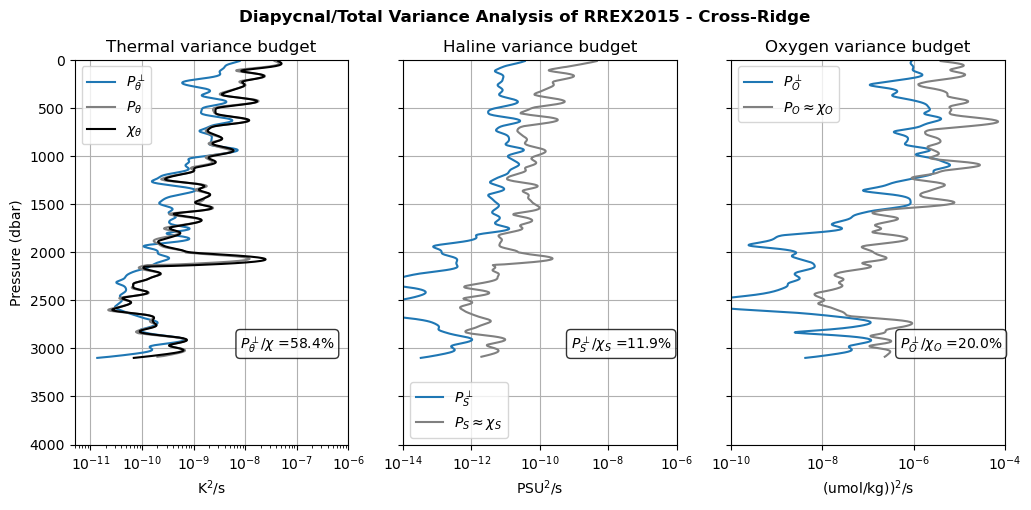

In [17]:
# Also using Osborn Krho
fig, ax = plt.subplots(1,3, sharey = True, figsize = (12,5))


ax[0].semilogx(Pdia_oz_m, pres_vmp,label ="$P_{\\theta}^{\\perp}$")
ax[0].semilogx(chi_dia_oz_m, pres_vmp, color = "gray", label ="$P_{\\theta}$" )
ax[0].semilogx(chi_oz_m,  pres_vmp, color = "k", label = "$\chi_{\\theta}$")
ax[0].set_ylim((4000,0))
ax[0].set_xlim((5e-12,1e-6))
ax[0].legend()
ax[0].set_ylabel("Pressure (dbar)")
ax[0].set_title("Thermal variance budget")
ax[0].set_xlabel("K$^2$/s")
ax[0].grid(True)
ax[0].text(8e-9, 3000, '$P_{\\theta}^{\\perp}/\chi$ =' + f'{dia_theta_oz_percent}%', 
           fontsize=10,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax[1].semilogx(PdiaS_oz_m, pres_vmp,label ="$P_S^{\\perp}$")
ax[1].semilogx(chiS_oz_m, pres_vmp, color = "gray", label = "$P_S \\approx \chi_S$")
ax[1].legend()
ax[1].set_title("Haline variance budget")
ax[1].set_xlabel("PSU$^2$/s")
ax[1].grid(True)
ax[1].set_ylim((4000,0))
ax[1].set_xlim((1e-14,1e-6))
ax[1].text(8e-10, 3000, '$P_S^{\\perp}/\chi_S$ =' + f'{dia_S_oz_percent}%', 
           fontsize=10,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax[2].semilogx(PdiaO_oz_m, pres_vmp,label ="$P_O^{\\perp}$")
ax[2].semilogx(chiO_oz_m, pres_vmp, color = "gray", label = "$P_O \\approx \chi_O$")
ax[2].legend()
ax[2].set_title("Oxygen variance budget")
ax[2].set_xlabel("(umol/kg))$^2$/s")
ax[2].grid(True)
ax[2].set_ylim((4000,0))
ax[2].set_xlim((1e-10,1e-4))
ax[2].text(5e-7, 3000, '$P_O^{\\perp}/\chi_O$ =' + f'{dia_O_oz_percent}%', 
           fontsize=10,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

figtitle=['Diapycnal/Total Variance Analysis of RREX2015 - Reykjanes Ridge',
          'Diapycnal/Total Variance Analysis of RREX2015 - West of Ridge',
          'Diapycnal/Total Variance Analysis of RREX2015 - East of Ridge',
          'Diapycnal/Total Variance Analysis of RREX2015 - Cross-Ridge (South)',
          'Diapycnal/Total Variance Analysis of RREX2015 - Cross-Ridge']

plt.suptitle(figtitle[location],fontsize=12,fontweight='bold')

figname=['RREX2015_Ridge_Os_VarianceBudget_Merged.png',
         'RREX2015_WRidge_Os_VarianceBudget_Merged.png',
         'RREX2015_ERidge_Os_VarianceBudget_Merged.png',
         'RREX2015_SouthXRidge_Os_VarianceBudget_Merged.png',
         'RREX2015_XRidge_Os_VarianceBudget_Merged.png']

#plt.savefig(figname[location]) 

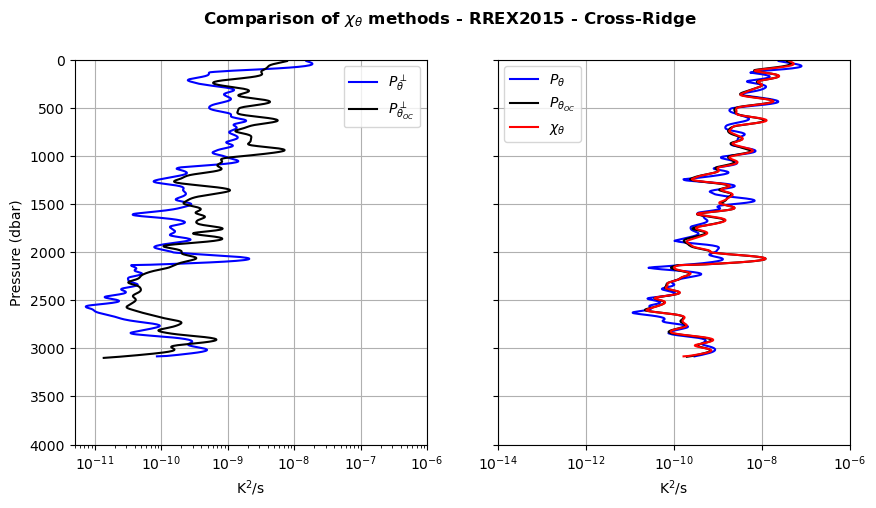

In [18]:
# Comparison between both methods for deriving Kp

fig, ax = plt.subplots(1,2, sharey = True, figsize = (10,5))


ax[0].semilogx(Pdia_m, pres_vmp, color = "b",label ="$P_{\\theta}^{\\perp}$")
ax[0].semilogx(Pdia_oz_m, pres_vmp, color = "k",label ="$P_{\\theta_{OC}}^{\\perp}$")
ax[0].set_ylim((4000,0))
ax[0].set_xlim((5e-12,1e-6))
ax[0].legend()
ax[0].set_ylabel("Pressure (dbar)")
#ax[0].set_title("Thermal variance budget")
ax[0].set_xlabel("K$^2$/s")
ax[0].grid(True)
#ax[0].text(8e-9, 3000, '$P_{\\theta}^{\\perp}/\chi$ =' + f'{dia_theta_oz_percent}%', 
#           fontsize=10,
#           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax[1].semilogx(chi_dia_m, pres_vmp, color = "blue", label ="$P_{\\theta}$" )
ax[1].semilogx(chi_dia_oz_m, pres_vmp, color = "black", label ="$P_{\\theta_{OC}}$" )
ax[1].semilogx(chi_m,  pres_vmp, color = "r", label = "$\chi_{\\theta}$")
ax[1].legend()
#ax[1].set_title("Haline variance budget")
ax[1].set_xlabel("K$^2$/s")
ax[1].grid(True)
ax[1].set_ylim((4000,0))
ax[1].set_xlim((1e-14,1e-6))


figtitle=['Comparison of $\chi_{\\theta}$ methods - RREX2015 - Along-Ridge',
          'Comparison of $\chi_{\\theta}$ methods - RREX2015 - West of Ridge',
          'Comparison of $\chi_{\\theta}$ methods - RREX2015 - East of Ridge',
          'Comparison of $\chi_{\\theta}$ methods - RREX2015 - Cross-Ridge (South)',
          'Comparison of $\chi_{\\theta}$ methods - RREX2015 - Cross-Ridge']

plt.suptitle(figtitle[location],fontsize=12,fontweight='bold')

figname=['RREX2015_Ridge_VarianceMethodComparison.png',
         'RREX2015_WRidge_VarianceMethodComparison.png',
         'RREX2015_ERidge_VarianceMethodComparison.png',
         'RREX2015_SouthXRidge_VarianceMethodComparison.png',
         'RREX2015_XRidge_VarianceMethodComparison.png']

#plt.savefig(figname[location]) 

/tmp/ipykernel_12800/1224984116.py:5: RuntimeWarning: Mean of empty slice
  ax[0].plot(np.nanmean(grT_mean,axis=1), pres_vmp, color = "b",label ="${\\nabla_{\\rho}}{\\theta}$")
/tmp/ipykernel_12800/1224984116.py:6: RuntimeWarning: Mean of empty slice
  ax[0].plot(np.nanmean(grT_mean_oz,axis=1), pres_vmp, color = "k",label ="${\\nabla_{z}}{\\theta}$")
/tmp/ipykernel_12800/1224984116.py:18: RuntimeWarning: Mean of empty slice
  ax[1].plot(np.nanmean(grS_mean,axis=1), pres_vmp, color = "b",label ="${\\nabla_{\\rho}}{S}$")
/tmp/ipykernel_12800/1224984116.py:19: RuntimeWarning: Mean of empty slice
  ax[1].plot(np.nanmean(grS_mean_oz,axis=1), pres_vmp, color = "k",label ="${\\nabla_{z}}{S}$")
/tmp/ipykernel_12800/1224984116.py:28: RuntimeWarning: Mean of empty slice
  ax[2].plot(np.nanmean(grO_mean,axis=1), pres_vmp, color = "b",label ="${\\nabla_{\\rho}}{O}$")
/tmp/ipykernel_12800/1224984116.py:29: RuntimeWarning: Mean of empty slice
  ax[2].plot(np.nanmean(grO_mean_oz,axis=1), pres_vmp, co

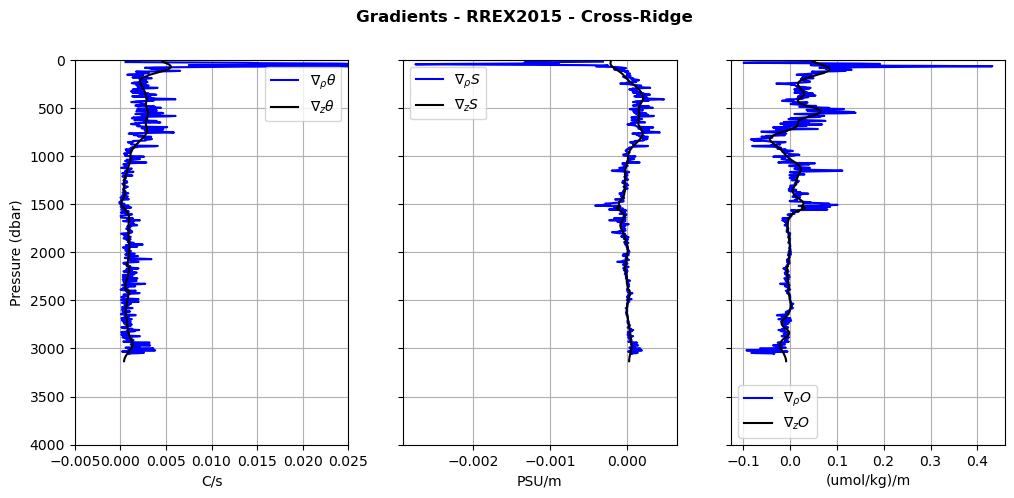

In [19]:
fig, ax = plt.subplots(1,3, sharey = True, figsize = (12,5))

# Compare vertical gradients

ax[0].plot(np.nanmean(grT_mean,axis=1), pres_vmp, color = "b",label ="${\\nabla_{\\rho}}{\\theta}$")
ax[0].plot(np.nanmean(grT_mean_oz,axis=1), pres_vmp, color = "k",label ="${\\nabla_{z}}{\\theta}$")
ax[0].set_ylim((4000,0))
ax[0].set_xlim((-0.005,0.025))
ax[0].legend()
ax[0].set_ylabel("Pressure (dbar)")
#ax[0].set_title("Thermal variance budget")
ax[0].set_xlabel("C/s")
ax[0].grid(True)
#ax[0].text(8e-9, 3000, '$P_{\\theta}^{\\perp}/\chi$ =' + f'{dia_theta_oz_percent}%', 
#           fontsize=10,
#           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax[1].plot(np.nanmean(grS_mean,axis=1), pres_vmp, color = "b",label ="${\\nabla_{\\rho}}{S}$")
ax[1].plot(np.nanmean(grS_mean_oz,axis=1), pres_vmp, color = "k",label ="${\\nabla_{z}}{S}$")
ax[1].legend()
#ax[1].set_title("Haline variance budget")
ax[1].set_xlabel("PSU/m")
ax[1].grid(True)
ax[1].set_ylim((4000,0))
#ax[1].set_xlim((1e-14,1e-6))


ax[2].plot(np.nanmean(grO_mean,axis=1), pres_vmp, color = "b",label ="${\\nabla_{\\rho}}{O}$")
ax[2].plot(np.nanmean(grO_mean_oz,axis=1), pres_vmp, color = "k",label ="${\\nabla_{z}}{O}$")
ax[2].legend()
#ax[2].set_title("Oxygen variance budget")
ax[2].set_xlabel("(umol/kg)/m")
ax[2].grid(True)
ax[2].set_ylim((4000,0))
#ax[2].set_xlim((1e-10,1e-4))

figtitle=['Gradients - RREX2015 - Along-Ridge',
          'Gradients - RREX2015 - West of Ridge',
          'Gradients - RREX2015 - East of Ridge',
          'Gradients - RREX2015 - Cross-Ridge (South)',
          'Gradients - RREX2015 - Cross-Ridge']

plt.suptitle(figtitle[location],fontsize=12,fontweight='bold')


figname=['RREX2015_Ridge_Gradients.png',
         'RREX2015_WRidge_Gradients.png',
         'RREX2015_ERidge_Gradients.png',
         'RREX2015_SouthXRidge_Gradients.png',
         'RREX2015_XRidge_Gradients.png']

#plt.savefig(figname[location]) 


# Final Figures Using Osborn and Cox Method

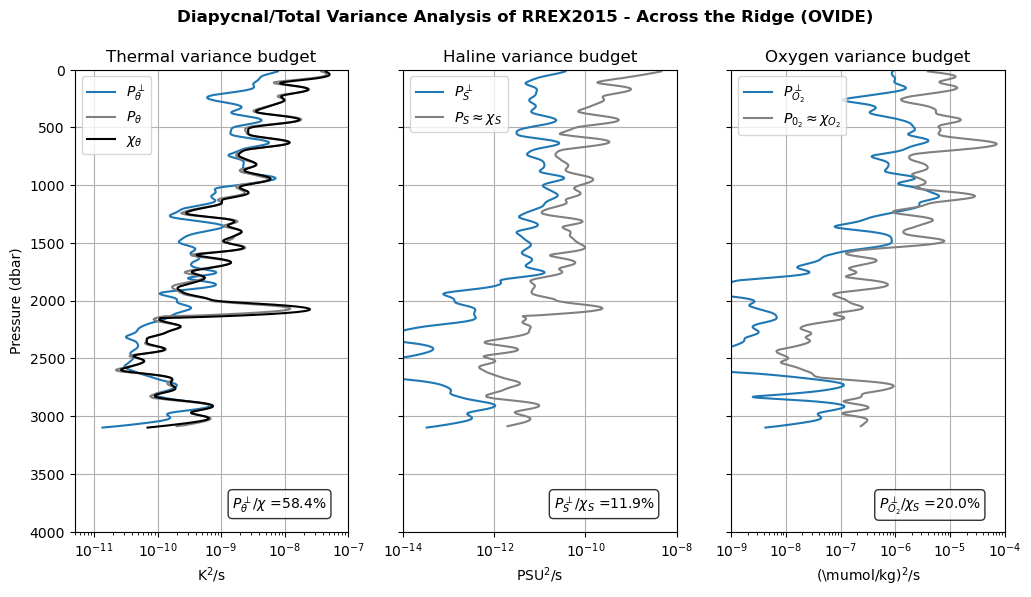

In [20]:
fig, ax = plt.subplots(1,3, sharey = True, figsize = (12,6))


ax[0].semilogx(Pdia_oz_m, pres_vmp,label ="$P_{\\theta}^{\\perp}$")
ax[0].semilogx(chi_dia_oz_m, pres_vmp, color = "gray", label ="$P_{\\theta}$" )
ax[0].semilogx(chi_oz_m,  pres_vmp, color = "k", label = "$\chi_{\\theta}$")
ax[0].set_ylim((4000,0))
ax[0].set_xlim((5e-12,1e-7))
ax[0].legend(loc='upper left')
ax[0].set_ylabel("Pressure (dbar)")
ax[0].set_title("Thermal variance budget")
ax[0].set_xlabel("K$^2$/s")
ax[0].grid(True)
ax[0].text(1.5e-9, 3800, '$P_{\\theta}^{\\perp}/\chi$ =' + f'{dia_theta_oz_percent}%', 
           fontsize=10,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax[1].semilogx(PdiaS_oz_m, pres_vmp,label ="$P_S^{\\perp}$")
ax[1].semilogx(chiS_oz_m, pres_vmp, color = "gray", label = "$P_S \\approx \chi_S$")
ax[1].legend(loc='upper left')
ax[1].set_title("Haline variance budget")
ax[1].set_xlabel("PSU$^2$/s")
ax[1].grid(True)
ax[1].set_ylim((4000,0))
ax[1].set_xlim((1e-14,1e-8))
ax[1].text(2e-11, 3800, '$P_S^{\\perp}/\\chi_S$ =' + f'{dia_S_oz_percent}%', 
           fontsize=10,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax[2].semilogx(PdiaO_oz_m, pres_vmp,label ="$P_{O_2}^{\\perp}$")
ax[2].semilogx(chiO_oz_m, pres_vmp, color = "gray", label = "$P_{0_2} \\approx \\chi_{O_2}$")
ax[2].legend(loc='upper left')
ax[2].set_title("Oxygen variance budget")
ax[2].set_xlabel("(\\mumol/kg)$^2$/s")
ax[2].grid(True)
ax[2].set_ylim((4000,0))
ax[2].set_xlim((1e-9,1e-4))
ax[2].text(5e-7, 3800, '$P_{O_2}^{\\perp}/\\chi_S$ =' + f'{dia_O_oz_percent}%', 
           fontsize=10,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

figtitle=['Diapycnal/Total Variance Analysis of RREX2015 - Reykjanes Ridge',
          'Diapycnal/Total Variance Analysis of RREX2015 - West of Ridge',
          'Diapycnal/Total Variance Analysis of RREX2015 - East of Ridge',
          'Diapycnal/Total Variance Analysis of RREX2015 - Across the Ridge (South)',
          'Diapycnal/Total Variance Analysis of RREX2015 - Across the Ridge (OVIDE)']

plt.suptitle(figtitle[location],fontsize=12,fontweight='bold')

figname=['1_RREX2015_Ridge_VarianceBudget.png',
         '2_RREX2015_WRidge_VarianceBudget.png',
         '3_RREX2015_ERidge_VarianceBudget.png',
         '4_RREX2015_SouthXRidge_VarianceBudget.png',
         '5_RREX2015_XRidge_VarianceBudget.png']

#plt.savefig(figname[location], dpi = 300, bbox_inches = "tight")

# Transects of Temperature, Salinity and Turbulent Variables

In [21]:
# Smooth fields

Ns = 30  # 120 meters
chi_smooth = np.full(chi.shape, np.nan)
Pdia_smooth = np.full(chi.shape, np.nan)
chiS_smooth = np.full(chi.shape, np.nan)
PdiaS_smooth = np.full(chi.shape, np.nan)
chiO_smooth = np.full(chi.shape, np.nan)
PdiaO_smooth = np.full(chi.shape, np.nan)

for i in range(lon_vmp.size):
    chi_smooth[:, i] = of.moving_average(chi[:, i], Ns)
    Pdia_smooth[:, i] = of.moving_average(Pdia_oz[:, i], Ns)

    chiS_smooth[:, i] = of.moving_average(chiS_oz[:, i], Ns)
    PdiaS_smooth[:, i] = of.moving_average(PdiaS_oz[:, i], Ns)

    chiO_smooth[:, i] = of.moving_average(chiO_oz[:, i], Ns)
    PdiaO_smooth[:, i] = of.moving_average(PdiaO_oz[:, i], Ns)

theta_percent_2d = np.round((Pdia_smooth/chi_smooth)*100, decimals=1)

Salt_percent_2d = np.round((PdiaS_smooth/chiS_smooth)*100, decimals=1)

oxy_percent_2d = np.round((PdiaO_smooth/chiO_smooth)*100, decimals=1)

# Define the x axis and y axis labels acording to the transect
if location == 0:
    xaxis = lat_vmp
    xaxis_label = "Latitude"
else:
    xaxis = lon_vmp
    xaxis_label = "Longitude"

# Sort the data so that the xaxis (longitude) is increasing
sort_idx = np.argsort(xaxis)
xaxis = xaxis[sort_idx]
chi_smooth = chi_smooth[:, sort_idx]
theta = theta[:, sort_idx]
SA = SA[:, sort_idx]
oxygen = oxygen[:, sort_idx]
gamman = gamman[:, sort_idx]
chiS_smooth = chiS_smooth[:, sort_idx]
chiO_smooth = chiO_smooth[:, sort_idx]
theta_percent_2d = theta_percent_2d[:, sort_idx]
Salt_percent_2d = Salt_percent_2d[:, sort_idx]
oxy_percent_2d = oxy_percent_2d[:, sort_idx]

zlabels = np.array([0, 500, 1500, 3000, 4000])

bottom = np.full(xaxis.size, np.nan)
for i in range(xaxis.size):
    ij = np.where(np.isfinite(chi_smooth[:, i]))[0][-1]
    bottom[i] = pres_vmp[ij]

# For some reason that I still can't explain, the bottom is "deeper"
# in chi with respect to theta

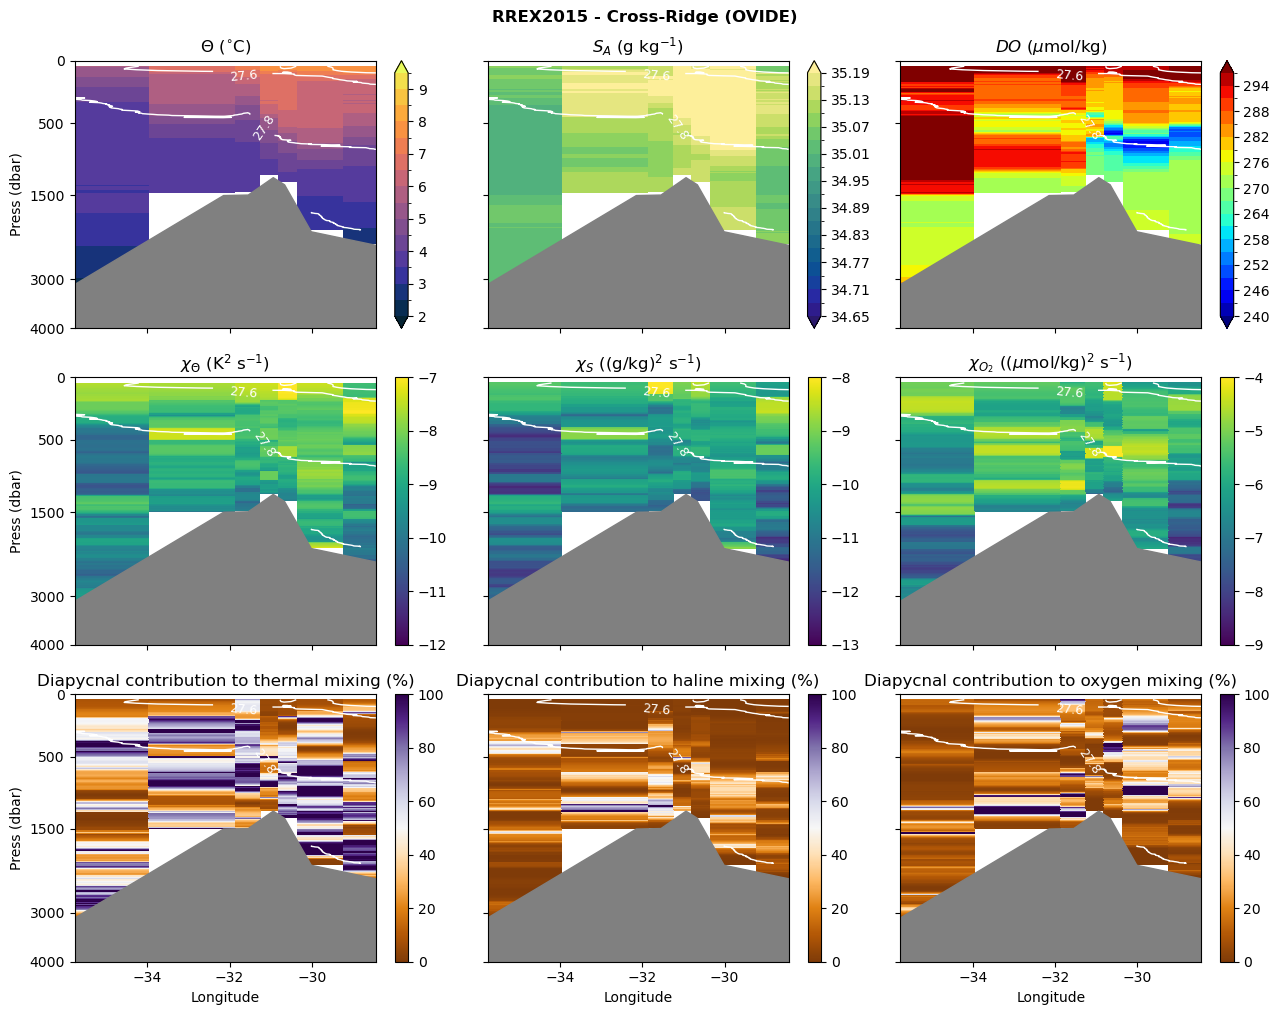

In [22]:
b = 0.7

# Making a 3*3 subplot of Temperature, Salinity, Oxygen, Xt, Xs, Xo2 and the diapycnal/isopycnal contribution
fig, ax = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(13, 10))

# First Row

# Plot of temperature
temperature_levels = np.arange(2, 10, 0.5)
norm = mcolors.BoundaryNorm(temperature_levels, ncolors=256, extend='both')
cc = ax[0, 0].pcolormesh(xaxis, pres_vmp**b, theta, cmap=cmocean.cm.thermal, norm=norm, shading='auto')
plt.colorbar(cc, ax=ax[0, 0])
cd = ax[0, 0].contour(xaxis, pres_vmp**b, gamman,
                np.arange(27.4, 28.2, 0.2), colors="w", linewidths=1)
plt.clabel(cd,fmt = "%1.1f", fontsize = 9)
ax[0,0].set_title("$\\Theta$ ($^{\\circ}$C)")

ax[0,0].set_ylim((max(zlabels)**b,0))
ax[0,0].set_yticks(zlabels**b)
ax[0,0].set_yticklabels(zlabels)
ax[0,0].set_ylabel("Press (dbar)")

# Plot of salinity
salinity_levels = np.arange(34.65, 35.2, 0.03)
norm = mcolors.BoundaryNorm(salinity_levels, ncolors=256, extend='both')
cc=ax[0,1].pcolormesh(xaxis,pres_vmp**b, SA, cmap = cmocean.cm.haline, norm=norm, shading = 'auto')
plt.colorbar(cc, ax = ax[0,1])
cd=ax[0,1].contour(xaxis, pres_vmp**b,gamman,\
                   np.arange(27.4,28.2,0.2),colors ="w", linewidths = 1)
plt.clabel(cd,fmt = "%1.1f", fontsize = 9)
ax[0,1].set_title("$S_A$ (g kg$^{-1}$)")

ax[0,1].set_ylim((max(zlabels)**b,0))
ax[0,1].set_yticks(zlabels**b)
ax[0,1].set_yticklabels(zlabels)

# Plot of Oxygen
oxygen_levels = np.arange(240, 300, 3)
norm = mcolors.BoundaryNorm(oxygen_levels, ncolors=256, extend='both')
cc=ax[0,2].pcolormesh(xaxis,pres_vmp**b,oxygen, cmap = 'jet', norm=norm, shading = 'auto')
plt.colorbar(cc, ax = ax[0,2])
cd=ax[0,2].contour(xaxis, pres_vmp**b,gamman,\
                   np.arange(27.4,28.2,0.2),colors ="w", linewidths = 1)
plt.clabel(cd,fmt = "%1.1f", fontsize = 9)
ax[0,2].set_title("$DO$ ($\\mu$mol/kg)")

ax[0,2].set_ylim((max(zlabels)**b,0))
ax[0,2].set_yticks(zlabels**b)
ax[0,2].set_yticklabels(zlabels)

## Second Row

# Plot of chi (measured)
cc=ax[1,0].pcolormesh(xaxis, pres_vmp**b,np.log10(chi_smooth), vmin = -12, vmax = -7)
plt.colorbar(cc, ax = ax[1,0])
cd=ax[1,0].contour(xaxis, pres_vmp**b,gamman,\
                   np.arange(27.4,28.2,0.2),colors ="w", linewidths = 1)
plt.clabel(cd,fmt = "%1.1f", fontsize = 9)
ax[1,0].set_title("$\\chi_{\\Theta}$ (K$^2$ s$^{-1}$)")

ax[1,0].set_ylim((max(zlabels)**b,0))
ax[1,0].set_yticks(zlabels**b)
ax[1,0].set_yticklabels(zlabels)
ax[1,0].set_ylabel("Press (dbar)")

# Plot of haline diffusivity (estimated)
cc=ax[1,1].pcolor(xaxis, pres_vmp**b,np.log10(chiS_smooth), vmin = -13, vmax = -8)
plt.colorbar(cc, ax = ax[1,1])
cd=ax[1,1].contour(xaxis, pres_vmp**b,gamman,\
                   np.arange(27.4,28.2,0.2),colors ="w", linewidths = 1)
plt.clabel(cd,fmt = "%1.1f", fontsize = 9)
ax[1,1].set_title("$\\chi_{S}$ ((g/kg)$^2$ s$^{-1}$)")

ax[1,1].set_ylim((max(zlabels)**b,0))
ax[1,1].set_yticks(zlabels**b)
ax[1,1].set_yticklabels(zlabels)

# Plot of oxygen diffusivity (estimated)
cc=ax[1,2].pcolor(xaxis, pres_vmp**b,np.log10(chiO_smooth), vmin = -9, vmax = -4)
plt.colorbar(cc, ax = ax[1,2])
cd=ax[1,2].contour(xaxis, pres_vmp**b,gamman,\
                   np.arange(27.4,28.2,0.2),colors ="w", linewidths = 1)
plt.clabel(cd,fmt = "%1.1f", fontsize = 9)
ax[1,2].set_title("$\\chi_{O_2}$ (($\\mu$mol/kg)$^2$ s$^{-1}$)")

ax[1,2].set_ylim((max(zlabels)**b,0))
ax[1,2].set_yticks(zlabels**b)
ax[1,2].set_yticklabels(zlabels)

## Third Row

# Plot of diapycnal/isopycnal contribution to temperature variance
cc=ax[2,0].pcolor(xaxis, pres_vmp**b,theta_percent_2d, vmin = 0, vmax = 100, cmap =cm.PuOr)
plt.colorbar(cc, ax = ax[2,0])
cd=ax[2,0].contour(xaxis, pres_vmp**b,gamman,\
                   np.arange(27.4,28.2,0.2),colors ="w", linewidths = 1)
plt.clabel(cd,fmt = "%1.1f", fontsize = 9)
ax[2,0].set_title("Diapycnal contribution to thermal mixing (%)")

ax[2,0].set_ylim((max(zlabels)**b,0))
ax[2,0].set_yticks(zlabels**b)
ax[2,0].set_yticklabels(zlabels)
ax[2,0].set_ylabel("Press (dbar)")

# Plot of diapycnal/isopycnal contribution to salinity variance
cc=ax[2,1].pcolor(xaxis, pres_vmp**b,Salt_percent_2d, vmin = 0, vmax = 100, cmap =cm.PuOr)
plt.colorbar(cc, ax = ax[2,1])
cd=ax[2,1].contour(xaxis, pres_vmp**b,gamman,\
                   np.arange(27.4,28.2,0.2),colors ="w", linewidths = 1)
plt.clabel(cd,fmt = "%1.1f", fontsize = 9)
ax[2,1].set_title("Diapycnal contribution to haline mixing (%)")

ax[2,1].set_ylim((max(zlabels)**b,0))
ax[2,1].set_yticks(zlabels**b)
ax[2,1].set_yticklabels(zlabels)

# Plot of diapycnal/isopycnal contribution to oxygen variance
cc=ax[2,2].pcolor(xaxis, pres_vmp**b,oxy_percent_2d, vmin = 0, vmax = 100, cmap =cm.PuOr)
plt.colorbar(cc, ax = ax[2,2])
cd=ax[2,2].contour(xaxis, pres_vmp**b,gamman,\
                   np.arange(27.4,28.2,0.2),colors ="w", linewidths = 1)
plt.clabel(cd,fmt = "%1.1f", fontsize = 9)
ax[2,2].set_title("Diapycnal contribution to oxygen mixing (%)")

ax[2,2].set_ylim((max(zlabels)**b,0))
ax[2,2].set_yticks(zlabels**b)
ax[2,2].set_yticklabels(zlabels)

ax[2,0].set_xlabel(xaxis_label)
ax[2,1].set_xlabel(xaxis_label)
ax[2,2].set_xlabel(xaxis_label)

# Add bottom
for ax0 in ax.ravel():
    ax0.fill_between(xaxis, y1 = max(zlabels)**b, y2 = bottom**b, color = "gray")
    ax0.set_xlim((np.min(xaxis), np.max(xaxis)))

fig.tight_layout()

figtitle=['RREX2015 - Along-Ridge',
          'RREX2015 - West of Ridge',
          'RREX2015 - East of Ridge',
          'RREX2015 - Cross-Ridge (South)',
          'RREX2015 - Cross-Ridge (OVIDE)']

plt.suptitle(figtitle[location],fontsize=12,fontweight='bold',y=1.01)

figname=['RREX2015_RidgeTransect.png',
         'RREX2015_WRidgeTransect.png',
         'RREX2015_ERidgeTransect.png',
         'RREX2015_SouthXRidgeTransect.png',
         'RREX2015_XRidgeTransect.png']

#fig.savefig(figname[location], dpi = 300, bbox_inches = "tight")

In [23]:
# Creates variables in density space

# Create a regular gamma_n grid
gamma_min = 27.2
gamma_max = 28.2
gamma_grid = np.arange(gamma_min, gamma_max, 0.02)  # Adjust spacing as needed

# Interpolates for density coordinates
theta_gamma = of.interpolate_to_density(theta, gamman, gamma_grid)
SA_gamma = of.interpolate_to_density(SA, gamman, gamma_grid)
oxygen_gamma = of.interpolate_to_density(oxygen, gamman, gamma_grid)
chi_gamma = of.interpolate_to_density(chi_smooth, gamman, gamma_grid)
chiS_gamma = of.interpolate_to_density(chiS_smooth, gamman, gamma_grid)
chiO_gamma = of.interpolate_to_density(chiO_smooth, gamman, gamma_grid)
theta_percent_gamma = of.interpolate_to_density(theta_percent_2d, gamman, gamma_grid)
salt_percent_gamma = of.interpolate_to_density(Salt_percent_2d, gamman, gamma_grid)
oxy_percent_gamma = of.interpolate_to_density(oxy_percent_2d, gamman, gamma_grid)

# Makes bins for density coordinates
theta_gamma_bin, gamma_bins = of.bin_to_density_grid(theta, gamman, gamma_grid)
SA_gamma_bin, _ = of.bin_to_density_grid(SA, gamman, gamma_grid)
oxygen_gamma_bin, _ = of.bin_to_density_grid(oxygen, gamman, gamma_grid)
chi_gamma_bin, _ = of.bin_to_density_grid(chi_smooth, gamman, gamma_grid)
chiS_gamma_bin, _ = of.bin_to_density_grid(chiS_smooth, gamman, gamma_grid)
chiO_gamma_bin, _ = of.bin_to_density_grid(chiO_smooth, gamman, gamma_grid)
theta_percent_gamma_bin, _ = of.bin_to_density_grid(theta_percent_2d, gamman, gamma_grid)
salt_percent_gamma_bin, _ = of.bin_to_density_grid(Salt_percent_2d, gamman, gamma_grid)
oxy_percent_gamma_bin, _ = of.bin_to_density_grid(oxy_percent_2d, gamman, gamma_grid)
gamma_centers = (gamma_bins[:-1] + gamma_bins[1:]) / 2

# Makes a bottom in density space
bottom_gamma = np.full(xaxis.size, np.nan)
for i in range(xaxis.size):
    ij = np.where(np.isfinite(theta_gamma[:, i]))[0][-1]
    bottom_gamma[i] = gamma_grid[ij]

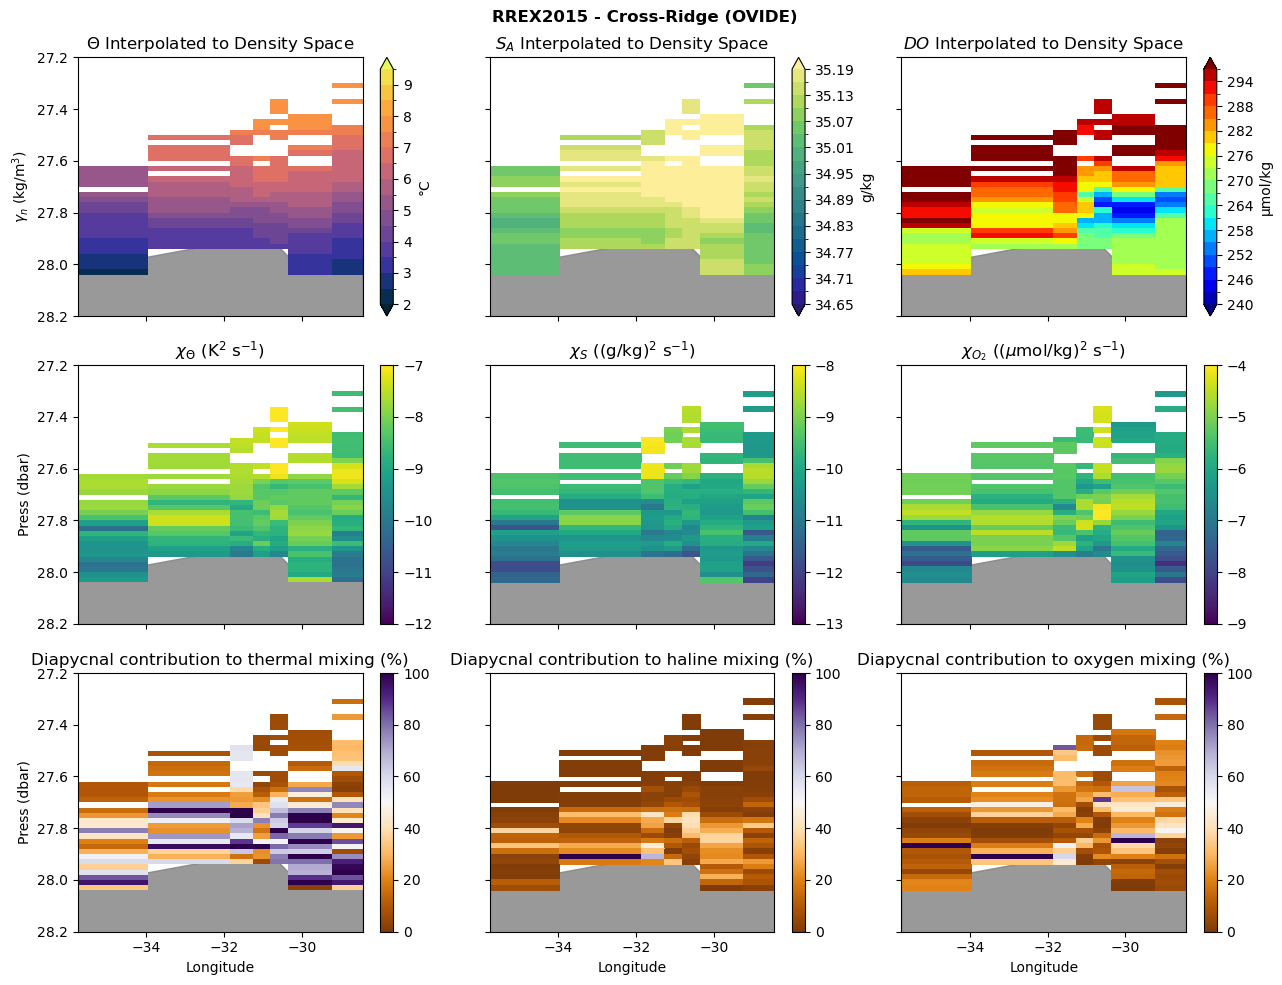

In [24]:
# Recreates plot of all variables but in density coordinates
aux = 1
y = gamma_grid

if aux == 0:
    y = gamma_grid
    z1 = theta_gamma
    z2 = SA_gamma
    z3 = oxygen_gamma
    z4 = chi_gamma
    z5 = chiS_gamma
    z6 = chiO_gamma
    z7 = theta_percent_gamma
    z8 = salt_percent_gamma
    z9 = oxy_percent_gamma
else:
    y = gamma_centers
    z1 = theta_gamma_bin
    z2 = SA_gamma_bin
    z3 = oxygen_gamma_bin
    z4 = chi_gamma_bin
    z5 = chiS_gamma_bin
    z6 = chiO_gamma_bin
    z7 = theta_percent_gamma_bin
    z8 = salt_percent_gamma_bin
    z9 = oxy_percent_gamma_bin


# Create new figure for density space plots
fig2, ax2 = plt.subplots(3, 3, sharex=True, sharey=True, figsize=(13, 10))

# Row 1: Hydrography

# Plot Temperature in density space
norm_temp = mcolors.BoundaryNorm(temperature_levels, ncolors=256, extend='both')
cc = ax2[0, 0].pcolormesh(xaxis, y, z1,
                       cmap=cmocean.cm.thermal,
                       norm=norm_temp,
                       shading='auto')
plt.colorbar(cc, ax=ax2[0, 0], label='°C')
ax2[0, 0].set_title("$\\Theta$ Interpolated to Density Space")
ax2[0, 0].set_ylabel("$\\gamma_n$ (kg/m$^3$)")

# Plot Salinity in density space
norm_sal = mcolors.BoundaryNorm(salinity_levels, ncolors=256, extend='both')
cc = ax2[0, 1].pcolormesh(xaxis, y, z2,
                       cmap=cmocean.cm.haline,
                       norm=norm_sal,
                       shading='auto')
plt.colorbar(cc, ax=ax2[0, 1], label='g/kg')
ax2[0, 1].set_title("$S_A$ Interpolated to Density Space")

# Plot Oxygen in density space
norm_oxy = mcolors.BoundaryNorm(oxygen_levels, ncolors=256, extend='both')
cc = ax2[0, 2].pcolormesh(xaxis, y, z3,
                       cmap='jet', 
                       norm=norm_oxy, 
                       shading='auto')
plt.colorbar(cc, ax=ax2[0, 2], label='μmol/kg')
ax2[0, 2].set_title("$DO$ Interpolated to Density Space")

# Row 2: Turbulence

# Plot of chi
cc = ax2[1, 0].pcolormesh(xaxis, y, np.log10(z4), vmin=-12, vmax=-7)
plt.colorbar(cc, ax=ax2[1, 0])
plt.clabel(cd,fmt="%1.1f", fontsize = 9)
ax2[1, 0].set_title("$\\chi_{\\Theta}$ (K$^2$ s$^{-1}$)")
ax2[1, 0].set_ylabel("Press (dbar)")

# Plot of haline diffusivity (estimated)
cc = ax2[1, 1].pcolor(xaxis, y, np.log10(z5), vmin=-13, vmax=-8)
plt.colorbar(cc, ax=ax2[1, 1])
plt.clabel(cd,fmt="%1.1f", fontsize = 9)
ax2[1, 1].set_title("$\\chi_{S}$ ((g/kg)$^2$ s$^{-1}$)")

# Plot of oxygen diffusivity (estimated)
cc = ax2[1, 2].pcolor(xaxis, y, np.log10(z6), vmin=-9, vmax=-4)
plt.colorbar(cc, ax=ax2[1, 2])
plt.clabel(cd, fmt="%1.1f", fontsize=9)
ax2[1, 2].set_title("$\\chi_{O_2}$ (($\\mu$mol/kg)$^2$ s$^{-1}$)")

# Row 3: Percentage

# Plot of chi
cc = ax2[2, 0].pcolormesh(xaxis, y, z7, vmin=0, vmax=100, cmap=cm.PuOr)
plt.colorbar(cc, ax=ax2[2, 0])
plt.clabel(cd,fmt="%1.1f", fontsize = 9)
ax2[2, 0].set_title("Diapycnal contribution to thermal mixing (%)")
ax2[2, 0].set_ylabel("Press (dbar)")

# Plot of haline diffusivity (estimated)
cc = ax2[2, 1].pcolor(xaxis, y, z8, vmin=0, vmax=100, cmap=cm.PuOr)
plt.colorbar(cc, ax=ax2[2, 1])
plt.clabel(cd,fmt="%1.1f", fontsize = 9)
ax2[2, 1].set_title("Diapycnal contribution to haline mixing (%)")

# Plot of oxygen diffusivity (estimated)
cc = ax2[2, 2].pcolor(xaxis, y, z9, vmin=0, vmax=100, cmap=cm.PuOr)
plt.colorbar(cc, ax=ax2[2, 2])
plt.clabel(cd, fmt="%1.1f", fontsize=9)
ax2[2,2].set_title("Diapycnal contribution to oxygen mixing (%)")


# Labels
ax2[2, 0].set_xlabel(xaxis_label)
ax2[2, 1].set_xlabel(xaxis_label)
ax2[2, 2].set_xlabel(xaxis_label)

# Add gray bottom to ALL subplots
for ax_row in ax2:
    for ax0 in ax_row:
        # Fill from top to bottom_gamma
        ax0.fill_between(xaxis, y1=gamma_max+0.1, y2=bottom_gamma,
                         color="gray", alpha=0.8, zorder=0)
        # Add black border along the bottom edge
        # ax0.plot(xaxis, bottom_gamma, color='black', linewidth=1, zorder=1)
        # Set y-axis limits
        ax0.set_ylim(gamma_max, gamma_min)
        ax0.set_xlim(xaxis.min(), xaxis.max())


figtitle=['RREX2015 - Along-Ridge',
          'RREX2015 - West of Ridge',
          'RREX2015 - East of Ridge',
          'RREX2015 - Cross-Ridge (South)',
          'RREX2015 - Cross-Ridge (OVIDE)']
plt.suptitle(figtitle[location],fontsize=12,fontweight='bold',y=0.98)

plt.tight_layout()
plt.show()

figname=['RREX2015_density_RidgeTransect.png',
         'RREX2015_density_WRidgeTransect.png',
         'RREX2015_density_ERidgeTransect.png',
         'RREX2015_density_SouthXRidgeTransect.png',
         'RREX2015_density_XRidgeTransect.png']
fig2.savefig(figname[location], dpi = 300, bbox_inches = "tight")

In [25]:
#  Creating vectorized and binned versions of the variables so I can visualite them in T-S space

# Create bins for T-S grid
SA_bins = np.linspace(34.6, 35.4, 60)  # Adjust based on your data range
theta_bins = np.linspace(1, 11, 50)     # Adjust based on your data range

# Bin the data
chi_grid = np.zeros((len(theta_bins)-1, len(SA_bins)-1))
chiS_grid = np.zeros((len(theta_bins)-1, len(SA_bins)-1))
chiO_grid = np.zeros((len(theta_bins)-1, len(SA_bins)-1))
theta_percent_grid = np.zeros((len(theta_bins)-1, len(SA_bins)-1))
salt_percent_grid = np.zeros((len(theta_bins)-1, len(SA_bins)-1))
oxy_percent_grid = np.zeros((len(theta_bins)-1, len(SA_bins)-1))
count_grid = np.zeros((len(theta_bins)-1, len(SA_bins)-1))

# Flatten arrays
SA_flat = SA.ravel()
theta_flat = theta.ravel()
chi_flat = chi_smooth.ravel()
chiS_flat = chiS_smooth.ravel()
chiO_flat = chiO_smooth.ravel()
theta_percent_flat = theta_percent_2d.ravel()
salt_percent_flat = Salt_percent_2d.ravel()
oxy_percent_flat = oxy_percent_2d.ravel()

# Remove NaNs
valid_mask = ~(np.isnan(SA_flat) | np.isnan(theta_flat) | np.isnan(chi_flat) | np.isnan(chiO_flat) | np.isnan(chiS_flat)
               | np.isnan(theta_percent_flat) | np.isnan(salt_percent_flat) | np.isnan(oxy_percent_flat))
SA_valid = SA_flat[valid_mask]
theta_valid = theta_flat[valid_mask]
chi_valid = chi_flat[valid_mask]
chiS_valid = chiS_flat[valid_mask]
chiO_valid = chiO_flat[valid_mask]
theta_percent_valid = theta_percent_flat[valid_mask]
salt_percent_valid = salt_percent_flat[valid_mask]
oxy_percent_valid = oxy_percent_flat[valid_mask]

# Bin the data
for i in range(len(SA_valid)):
    SA_idx = np.digitize(SA_valid[i], SA_bins) - 1  # finds which bin a value belongs to so it depends on
    theta_idx = np.digitize(theta_valid[i], theta_bins) - 1  # the actual value of SA and theta and the chosen bins (-1 for python indexing)
    
    if 0 <= SA_idx < chi_grid.shape[1] and 0 <= theta_idx < chi_grid.shape[0]:  # This checks if the indices are withn the grid boundaries
        chi_grid[theta_idx, SA_idx] += np.log10(chi_valid[i])  # We use += to sum all chi values inside the bin
        chiS_grid[theta_idx, SA_idx] += np.log10(chiS_valid[i])
        chiO_grid[theta_idx, SA_idx] += np.log10(chiO_valid[i])
        theta_percent_grid[theta_idx, SA_idx] += theta_percent_valid[i]
        salt_percent_grid[theta_idx, SA_idx] += salt_percent_valid[i]
        oxy_percent_grid[theta_idx, SA_idx] += oxy_percent_valid[i]
        count_grid[theta_idx, SA_idx] += 1 # Increment the bin counter to keep track of how many data points are containned in the bin

# Average the binned data
mask = count_grid > 0  # Makes a mask for bins with data
chi_grid[mask] /= count_grid[mask]  # Divides the summed values by the ammount of data per bin. is the same as: chi_grid = chi_grid / count_grid
chiS_grid[mask] /= count_grid[mask]
chiO_grid[mask] /= count_grid[mask]
theta_percent_grid[mask] /= count_grid[mask]
salt_percent_grid[mask] /= count_grid[mask]
oxy_percent_grid[mask] /= count_grid[mask]
chi_grid[~mask] = np.nan  # NaN for bin with no data
chiS_grid[~mask] = np.nan
chiO_grid[~mask] = np.nan
theta_percent_grid[~mask] = np.nan
salt_percent_grid[~mask] = np.nan
oxy_percent_grid[~mask] = np.nan

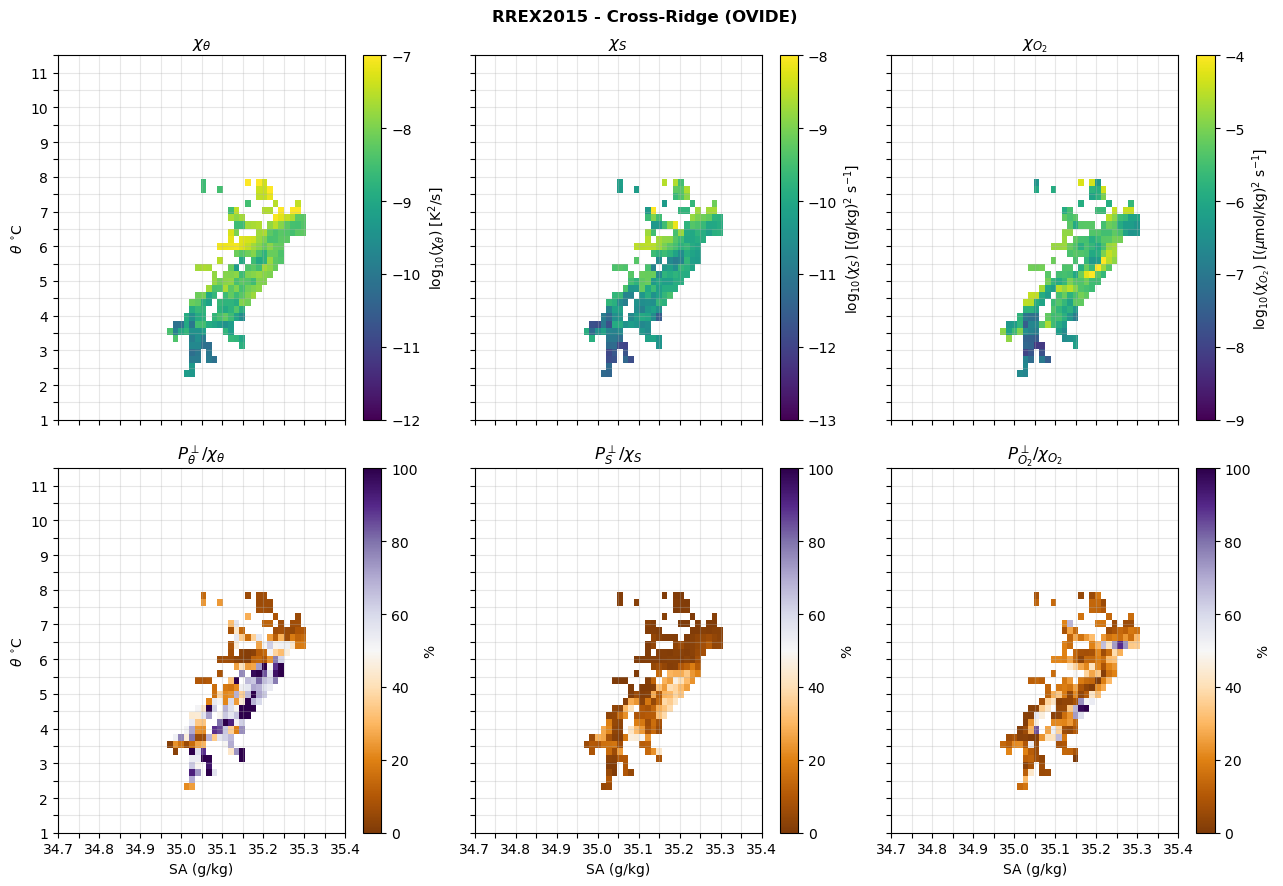

In [26]:
#  Ploting turbulence in T-S space

# Making a 2*3 subplot of Xi and the percentage in T-S space (Binned data)
fig, ax = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(13, 9))

# Thermal Data

cc = ax[0, 0].pcolormesh(SA_bins, theta_bins, chi_grid, 
                   vmin=-12, vmax=-7, shading='auto')
plt.colorbar(cc, ax=ax[0, 0], label='log$_{10}$($\\chi_{\\theta}$) [K$^2$/s]')
ax[0,0].set_title('$\\chi_{\\theta}$')
ax[0,0].grid(True, alpha=0.3, which='both')
ax[0,0].set_ylim((1, 11))
ax[0,0].set_xlim((34.7, 35.4))
ax[0,0].set_ylabel("$\\theta$ $^{\\circ}$C")
tick_positions = np.arange(1, 12, 0.5)
tick_labels = [f'{val:.0f}' if i % 2 == 0 else '' for i, val in enumerate(tick_positions)] # Set labels only for every other tick (7 labels)
ax[0,0].set_yticks(tick_positions)
ax[0,0].set_yticklabels(tick_labels)

cc = ax[1, 0].pcolormesh(SA_bins, theta_bins, theta_percent_grid, 
                   cmap=cm.PuOr, vmin=0, vmax=100, shading='auto')
plt.colorbar(cc, ax=ax[1, 0], label='%')
ax[1,0].set_title('$P_{\\theta}^{\\perp}/\\chi_{\\theta}$')
ax[1,0].set_ylabel("$\\theta$ $^{\\circ}$C")
ax[1,0].set_xlabel('SA (g/kg)')
tick_positions = np.arange(34.7, 35.45, 0.05)
tick_labels = [f'{val:.1f}' if i % 2 == 0 else '' for i, val in enumerate(tick_positions)] # Set labels only for every other tick 
ax[1,0].set_xticks(tick_positions)
ax[1,0].set_xticklabels(tick_labels)
ax[1,0].grid(True, alpha=0.3, which='both')

# Haline Data

cc = ax[0, 1].pcolormesh(SA_bins, theta_bins, chiS_grid, 
                   vmin=-13, vmax=-8, shading='auto')
plt.colorbar(cc, ax=ax[0, 1], label='log$_{10}$($\\chi_{S}$) [(g/kg)$^2$ s$^{-1}$]')
ax[0,1].set_title('$\\chi_{S}$')
ax[0,1].grid(True, alpha=0.3, which='both')

cc = ax[1, 1].pcolormesh(SA_bins, theta_bins, salt_percent_grid, 
                   cmap=cm.PuOr, vmin=0, vmax=100, shading='auto')
plt.colorbar(cc, ax=ax[1, 1], label='%')
ax[1,1].set_title('$P_{S}^{\\perp}/\\chi_S$')
ax[1,1].set_xlabel('SA (g/kg)')
ax[1,1].set_xticklabels(tick_labels)
ax[1,1].grid(True, alpha=0.3, which='both')

# Oxygen Data

cc = ax[0, 2].pcolormesh(SA_bins, theta_bins, chiO_grid, 
                   vmin=-9, vmax=-4, shading='auto')
plt.colorbar(cc, ax=ax[0, 2], label='log$_{10}$($\\chi_{O_2}$) [($\\mu$mol/kg)$^2$ s$^{-1}$]')
ax[0,2].set_title('$\\chi_{O_2}$')
ax[0,2].grid(True, alpha=0.3, which='both')

cc = ax[1, 2].pcolormesh(SA_bins, theta_bins, oxy_percent_grid, 
                   cmap=cm.PuOr, vmin=0, vmax=100, shading='auto')
plt.colorbar(cc, ax=ax[1, 2], label='%')
ax[1,2].set_title('$P_{O_2}^{\\perp}/\\chi_{O_2}$')
ax[1,2].set_xlabel('SA (g/kg)')
ax[1,2].set_xticklabels(tick_labels)
ax[1,2].grid(True, alpha=0.3, which='both')

figtitle=['RREX2015 - Along-Ridge',
          'RREX2015 - West of Ridge',
          'RREX2015 - East of Ridge',
          'RREX2015 - Cross-Ridge (South)',
          'RREX2015 - Cross-Ridge (OVIDE)']

plt.suptitle(figtitle[location],fontsize=12,fontweight='bold',y=0.98)
fig.tight_layout()
plt.show()

figname=['a_RREX2015_TS_Ridge.png',
         'b_RREX2015_TS_WRidge.png',
         'c_RREX2015_TS_ERidge.png',
         'd_RREX2015_TS_SouthXRidge.png',
         'e_RREX2015_TS_XRidge.png']

fig.savefig(figname[location], dpi = 300, bbox_inches = "tight")